# Task on Linear Regression

You are required to build a Linear Regression model to predict insurance charges based on patient information.

Here is the dataset:
https://www.kaggle.com/datasets/mirichoi0218/insurance

---

## Part 1: Data Understanding

Start by exploring the dataset carefully:

- Understand what each feature represents
- Identify input variables and target variable
- Check structure, data types, and completeness of the data


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(f"the shape :{df.shape}\n")
print("*^*^"*7)
print(f"Null values\n{df.isnull().sum()}\n")
print(f"Null values : {df.isnull().sum().sum()}\n")
print("*^*^"*7)
col = df.columns.to_list()
col

the shape :(1338, 7)

*^*^*^*^*^*^*^*^*^*^*^*^*^*^
Null values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Null values : 0

*^*^*^*^*^*^*^*^*^*^*^*^*^*^


['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## Part 2: Data Analysis & Insights

Before applying any model, you must analyze the dataset and extract insights.

You are expected to:

- Explore relationships between variables
- Identify patterns, trends
- Understand what factors may influence insurance cost

There is no restriction on tools or methods.
You are free to use any approach that helps you understand the data better.

The most important part here is:

**What did you learn from the data?**


In [7]:
import seaborn as sns


In [8]:
col

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

<Axes: xlabel='age', ylabel='charges'>

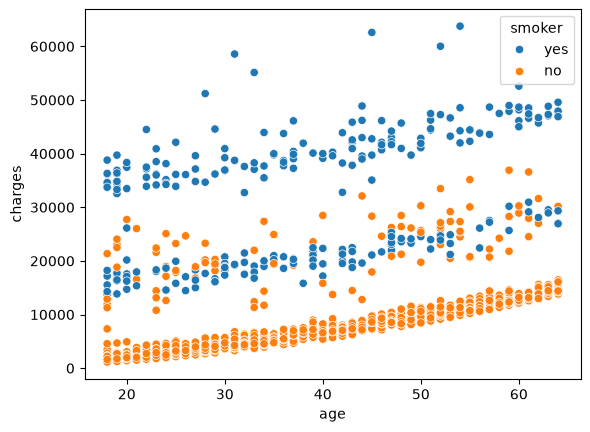

In [9]:
sns.scatterplot(x=df["age"], y=df["charges"], hue=df["smoker"] ,color="g")

Smoking status appears to have a strong association with insurance charges in this dataset.

<Axes: xlabel='bmi', ylabel='charges'>

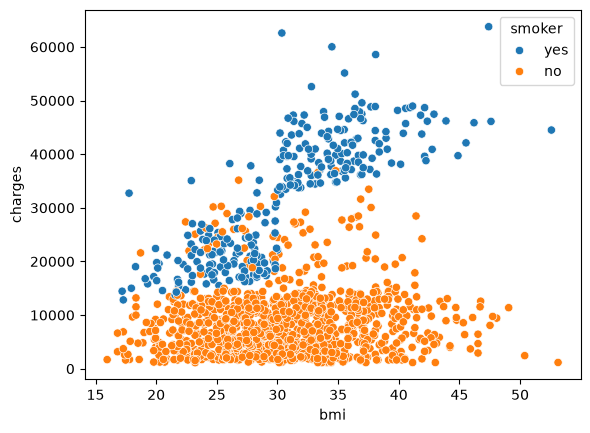

In [10]:
sns.scatterplot(
x=df["bmi"],
y=df["charges"],
hue=df["smoker"]
)

There appears to be a positive relationship between BMI and insurance charges, especially among smokers. However, smoking status appears to have a stronger association with charges than BMI alone. Among non-smokers, the relationship between BMI and charges is less clear.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_11532\869793463.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df , x="region" , y ="charges" , palette="Set3")


<Axes: xlabel='region', ylabel='charges'>

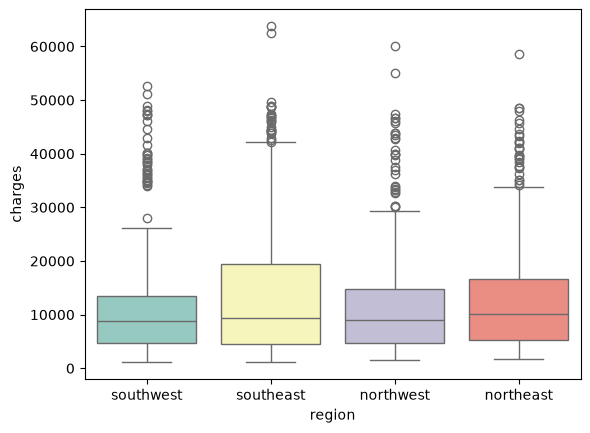

In [11]:
sns.boxplot(data=df , x="region" , y ="charges" , palette="Set3")

Insurance charges show some variation across regions, but the distributions overlap considerably. Therefore, region appears to have a weaker association with charges compared with smoking status.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_11532\67282429.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


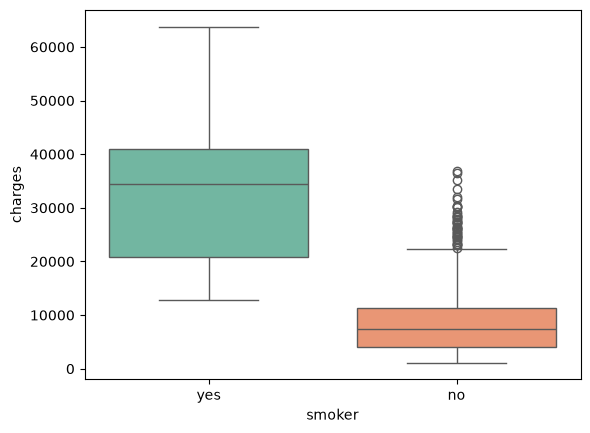

In [12]:
sns.boxplot(
    data=df,
    x="smoker",
    y="charges",
    palette="Set2"
)
plt.show()

Smoking status is strongly associated with insurance charges.
Smokers have a much higher median insurance charge than non-smokers, while non-smokers have several high-value outliers.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_11532\3801414941.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df ,


<Axes: xlabel='children', ylabel='charges'>

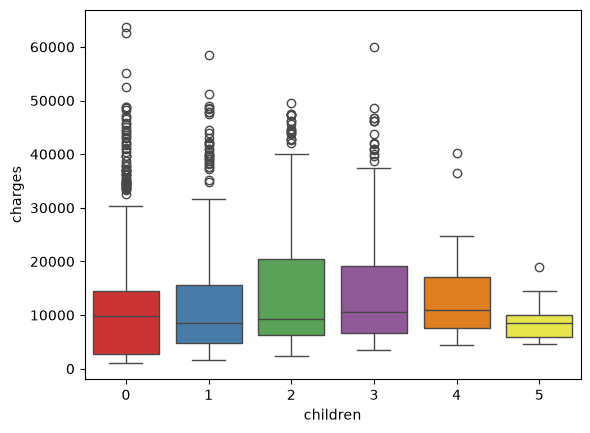

In [13]:
sns.boxplot(data=df ,
    x="children" ,
    y="charges" ,
    palette="Set1"
    )

The number of children does not show a clear linear or monotonic relationship with insurance charges. The distributions overlap considerably, although some differences in the median charges can be observed.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_11532\985489991.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df ,


<Axes: xlabel='sex', ylabel='charges'>

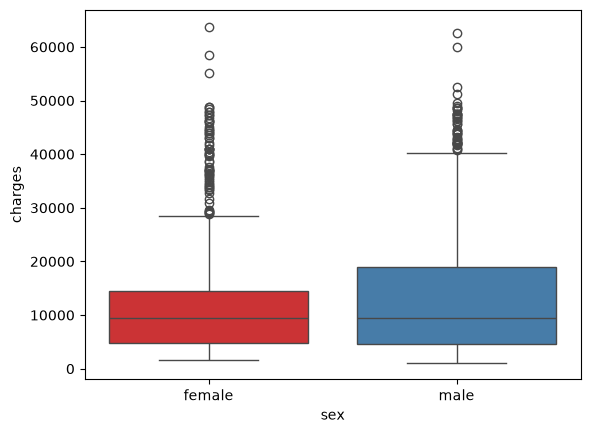

In [14]:
sns.boxplot(data=df ,
    x="sex" ,
    y="charges" ,
    palette="Set1"
    )

Insurance charges show some differences between males and females, but the distributions overlap considerably. Therefore, sex appears to have a weaker association with charges compared with smoking status.

<Axes: >

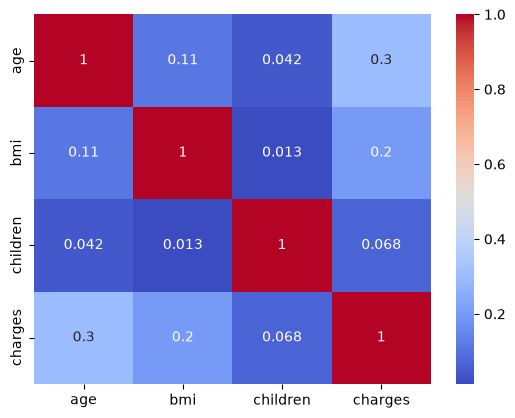

In [15]:
corr = df[["age", "bmi", "children", "charges"]].corr()
sns.heatmap(
    corr ,
    annot=True,
    cmap="coolwarm"
)

Age has the highest correlation with charges (0.30), followed by BMI (0.20). Children has a very weak correlation with charges (0.068). So, age and BMI have some positive relationship with charges, while children has almost no linear relationship.

=================================================================================================================================================

## Part 3: Data Preprocessing

Prepare the data for modeling:

- Handle missing values if any exist (and explain your decision)
- Encode categorical variables appropriately
- Apply feature scaling when needed
- Ensure dataset is clean and ready for machine learning


In [16]:
x = df.drop("charges", axis=1)
y = df["charges"]

In [17]:
print(f"Shape of X (Features) :{x.shape}")
print(f"Shape of y (Target) :  {y.shape}")
x.dtypes

Shape of X (Features) :(1338, 6)
Shape of y (Target) :  (1338,)


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
dtype: object

In [18]:
print(x["sex"].unique())
print(x["sex"].dtype)

<StringArray>
['female', 'male']
Length: 2, dtype: str
str


In [19]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [20]:
x["sex"].map({"male":1 , "female":0}).unique()

array([0, 1])

In [21]:
x["sex"] =x["sex"].map({"male":1 , "female":0})
x.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,yes,southwest
1,18,1,33.770,1,no,southeast
2,28,1,33.000,3,no,southeast
3,33,1,22.705,0,no,northwest
4,32,1,28.880,0,no,northwest


In [22]:
x["smoker"] = x["smoker"].map({"no":0 , "yes":1})

In [23]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,southwest
1,18,1,33.770,1,0,southeast
2,28,1,33.000,3,0,southeast
3,33,1,22.705,0,0,northwest
4,32,1,28.880,0,0,northwest


In [25]:
region_encoded = pd.get_dummies(
    x["region"],
    prefix="region",
    dtype=int
)

x = pd.concat([x.drop("region",axis=1), region_encoded], axis=1)

In [26]:
x.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0


## Part 4: Linear Regression Model

- Split the dataset into training and testing sets
- Train a Linear Regression model using training data
- Make predictions on unseen test data


In [ ]:
from sklearn.model_selection import train_test_split

In [29]:
x_train , x_test , y_train , y_test = train_test_split(
    x , y , test_size=0.2 , random_state=64
    )

In [37]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1070, 9)
(1070,)
(268, 9)
(268,)


## Part 5: Model Evaluation

Evaluate your model using regression metrics such as:

- MAE
- MSE
- RMSE
- R² Score


## Part 6: Final Insights & Conclusion

At the end, you should summarize:

- Key insights discovered from the dataset
- How these insights influenced your preprocessing or modeling choices
- Whether Linear Regression is a suitable model for this problem
- Possible improvements or next steps
